# Data Preprocessing without feature selection




## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import zscore
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.model_selection import KFold
import os
from sklearn.pipeline import Pipeline


In [2]:
df = pd.read_csv("train.csv")
final = pd.read_csv("test.csv")
farmer_id_final = final['FarmerID']

###INITITAL CLEANER CLASS

In [3]:
class InitialCleaner(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.temp_cols = [
            'K021-Ambient temperature (min & max)',
            'K022-Ambient temperature (min & max)',
            'R020-Ambient temperature (min & max)',
            'R021-Ambient temperature (min & max)',
            'R022-Ambient temperature (min & max)'
        ]
        self.cols_to_drop = [
            'Location', 'Address type', 'Ownership',
            'FarmerID', 'Unnamed: 0',
            'CITY', 'DISTRICT', 'Zipcode', 'VILLAGE'
        ]
        # Location ,address type, ownership dropped due to high missing values ~40percent
        # Farmer id, Unnamed 0, 
        # CITY DISTRICT ZIPCODE VILLAGE High cardinality columns that is why they ae removed

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X = X.drop(columns=[c for c in self.cols_to_drop if c in X.columns], errors='ignore')
        
        # fixing marital status, part of data formating
        if 'MARITAL_STATUS' in X.columns:
            X['MARITAL_STATUS'] = X['MARITAL_STATUS'].replace('NK', 'M')
        
        # Split temperature
        for col in self.temp_cols:
            if col in X.columns:
                split = X[col].str.split('/', expand=True)
                X[f'{col}_min'] = pd.to_numeric(split[0], errors='coerce')
                X[f'{col}_max'] = pd.to_numeric(split[1], errors='coerce')
                X.drop(columns=[col], inplace=True)
        return X

###AGGREGATING MULTI YEAR DATA CLASS

In [4]:
class MultiYearAggregator(BaseEstimator, TransformerMixin):
    """Aggregates numerical groups (mean only) and categorical groups (mode)."""
    def __init__(self, use_std=False):
        self.use_std = use_std
        self.num_groups_ = None  

    def fit(self, X, y=None):
        self.num_groups_ = {
            'rainfall': [c for c in X.columns if 'Seasonal Average Rainfall' in c],
            'groundwater_thickness': self._find_cols(X, 'groundwater thickness', ['Kharif','Rabi'], [2020,2021,2022]),
            'groundwater_replenishment': self._find_cols(X, 'groundwater replenishment rate', ['Kharif','Rabi'], [2020,2021,2022]),
            'agricultural_performance': self._find_cols(X, 'Agricultural performance', ['Kharif','Rabi'], [2020,2021,2022]),
            'agricultural_score': self._find_cols(X, 'Agricultural Score', ['Kharif','Rabi'], [2020,2021,2022]),
            'cropping_density': self._find_cols(X, 'Cropping density', ['Kharif','Rabi'], [2020,2021,2022]),
            'irrigated_area': self._find_cols(X, 'Irrigated area', ['Kharif','Rabi'], [2020,2021,2022])
        }
        
        self.temp_groups_ = self._find_temp_groups(X)
        
        self.cat_groups_ = {
            'soil_type': [c for c in X.columns if 'Type of soil' in c],
            'water_body_type': [c for c in X.columns if 'Type of water bodies' in c],
            'agro_zone': [c for c in X.columns if 'Agro Ecological Sub Zone' in c]
        }
        
        self.temp_fill_means_ = {}
        for name, cols in self.temp_groups_.items():
            dfg = pd.DataFrame({c: pd.to_numeric(X[c], errors='coerce') for c in cols if c in X.columns})
            self.temp_fill_means_[name] = dfg.mean()
        return self

    def _find_cols(self, X, pattern, seasons, years):
        cols = []
        for s in seasons:
            for y in years:
                pat = f"{s} Seasons"
                cols.extend([c for c in X.columns if pat in c and pattern in c and str(y) in c])
        return cols

    def _find_temp_groups(self, X):
        groups = {'kharif_min': [], 'kharif_max': [], 'rabi_min': [], 'rabi_max': []}
        for c in X.columns:
            if 'Ambient temperature' not in c:
                continue
            if 'K0' in c:
                if c.endswith('_min'):
                    groups['kharif_min'].append(c)
                elif c.endswith('_max'):
                    groups['kharif_max'].append(c)
            elif 'R0' in c:
                if c.endswith('_min'):
                    groups['rabi_min'].append(c)
                elif c.endswith('_max'):
                    groups['rabi_max'].append(c)
        return groups

    def transform(self, X):
        X = X.copy()
        dropped = []

        for name, cols in self.num_groups_.items():
            if len(cols) < 2:
                continue
            dfg = pd.DataFrame()
            for c in cols:
                if c in X.columns:
                    dfg[c] = pd.to_numeric(X[c], errors='coerce')
            if dfg.shape[1] < 2:
                continue
            dfg = dfg.apply(lambda col: col.fillna(dfg.median(axis=1)), axis=0)
            X[f'{name}_mean'] = dfg.mean(axis=1)
            if self.use_std:
                X[f'{name}_std'] = dfg.std(axis=1)
            dropped.extend(cols)

        for name, cols in self.temp_groups_.items():
            if len(cols) < 2:
                continue
            dfg = pd.DataFrame()
            for c in cols:
                if c in X.columns:
                    dfg[c] = pd.to_numeric(X[c], errors='coerce')
            dfg = dfg.fillna(self.temp_fill_means_[name])
            X[f'{name}_mean'] = dfg.mean(axis=1)
            dropped.extend(cols)

        for newcol, cols in self.cat_groups_.items():
            if cols:
                X[newcol] = X[cols].mode(axis=1)[0]
                dropped.extend(cols)

        if dropped:
            X = X.drop(columns=[c for c in dropped if c in X.columns])
        return X


In [5]:
# def aggregate_numerical_features(df):
#     df = df.copy()
    
#     numerical_groups = {
#         'rainfall': {
#             'pattern': 'Seasonal Average Rainfall',
#             'seasons': ['K021', 'K022', 'R020', 'R021', 'R022'],
#             'cols': []
#         },
#         'groundwater_thickness': {
#             'pattern': 'groundwater thickness',
#             'seasons': ['Kharif', 'Rabi'],
#             'years': [2020, 2021, 2022],
#             'cols': []
#         },
#         'groundwater_replenishment': {
#             'pattern': 'groundwater replenishment rate',
#             'seasons': ['Kharif', 'Rabi'],
#             'years': [2020, 2021, 2022],
#             'cols': []
#         },
#         'agricultural_performance': {
#             'pattern': 'Agricultural performance',
#             'seasons': ['Kharif', 'Rabi'],
#             'years': [2020, 2021, 2022],
#             'cols': []
#         },
#         'agricultural_score': {
#             'pattern': 'Agricultural Score',
#             'seasons': ['Kharif', 'Rabi'],
#             'years': [2020, 2021, 2022],
#             'cols': []
#         },
#         'cropping_density': {
#             'pattern': 'Cropping density',
#             'seasons': ['Kharif', 'Rabi'],
#             'years': [2020, 2021, 2022],
#             'cols': []
#         },
#         'irrigated_area': {
#             'pattern': 'Irrigated area',
#             'seasons': ['Kharif', 'Rabi'],
#             'years': [2020, 2021, 2022],
#             'cols': []
#         }
#     }
    
#     rainfall_cols = [col for col in df.columns if 'Seasonal Average Rainfall' in col]
#     if rainfall_cols:
#         numerical_groups['rainfall']['cols'] = rainfall_cols
    
#     for group_name, group_info in numerical_groups.items():
#         if group_name == 'rainfall':
#             continue
#         group_cols = []
#         for season in group_info['seasons']:
#             for year in group_info['years']:
#                 pattern = f"{season} Seasons"
#                 matching = [col for col in df.columns 
#                           if pattern in col 
#                           and group_info['pattern'] in col
#                           and str(year) in col]
#                 group_cols.extend(matching)
#         if group_cols:
#             numerical_groups[group_name]['cols'] = group_cols
    
#     dropped_cols = []
    
#     for group_name, group_info in numerical_groups.items():
#         group_cols = group_info.get('cols', [])
        
#         if len(group_cols) >= 2:
#             group_data = pd.DataFrame()
#             valid_cols = []
            
#             for col in group_cols:
#                 if col in df.columns:
#                     group_data[col] = pd.to_numeric(df[col], errors='coerce')
#                     valid_cols.append(col)
            
#             if len(valid_cols) >= 2:
#                 row_medians = group_data.median(axis=1)
#                 group_data = group_data.apply(lambda col: col.fillna(row_medians))
                
#                 mean_col = f'{group_name}_mean'
#                 # std_col = f'{group_name}_std'
                
#                 df[mean_col] = group_data.mean(axis=1)
#                 # df[std_col] = group_data.std(axis=1)
#                 dropped_cols.extend(valid_cols)
    
#     if dropped_cols:
#         df = df.drop(columns=[col for col in dropped_cols if col in df.columns])
    
#     return df


# def aggregate_temperature_by_season(df):
#     df = df.copy()
    
#     all_temp_cols = [col for col in df.columns if 'Ambient temperature' in col]
    
#     kharif_min_cols = []
#     kharif_max_cols = []
#     rabi_min_cols = []
#     rabi_max_cols = []
    
#     for col in all_temp_cols:
#         if 'K0' in col:
#             if col.endswith('_min'):
#                 kharif_min_cols.append(col)
#             elif col.endswith('_max'):
#                 kharif_max_cols.append(col)
#         elif 'R0' in col:
#             if col.endswith('_min'):
#                 rabi_min_cols.append(col)
#             elif col.endswith('_max'):
#                 rabi_max_cols.append(col)
    
#     dropped_cols = []
    
#     if kharif_min_cols:
#         kharif_min_data = pd.DataFrame()
#         for col in kharif_min_cols:
#             kharif_min_data[col] = pd.to_numeric(df[col], errors='coerce')
#         df['kharif_temp_min_mean'] = kharif_min_data.mean(axis=1)
#         dropped_cols.extend(kharif_min_cols)
    
#     if kharif_max_cols:
#         kharif_max_data = pd.DataFrame()
#         for col in kharif_max_cols:
#             kharif_max_data[col] = pd.to_numeric(df[col], errors='coerce')
#         df['kharif_temp_max_mean'] = kharif_max_data.mean(axis=1)
#         dropped_cols.extend(kharif_max_cols)
    
#     if rabi_min_cols:
#         rabi_min_data = pd.DataFrame()
#         for col in rabi_min_cols:
#             rabi_min_data[col] = pd.to_numeric(df[col], errors='coerce')
#         df['rabi_temp_min_mean'] = rabi_min_data.mean(axis=1)
#         dropped_cols.extend(rabi_min_cols)
    
#     if rabi_max_cols:
#         rabi_max_data = pd.DataFrame()
#         for col in rabi_max_cols:
#             rabi_max_data[col] = pd.to_numeric(df[col], errors='coerce')
#         df['rabi_temp_max_mean'] = rabi_max_data.mean(axis=1)
#         dropped_cols.extend(rabi_max_cols)
    
#     if dropped_cols:
#         df = df.drop(columns=[col for col in dropped_cols if col in df.columns])
    
#     return df


# def aggregate_categorical_features(df):
#     df = df.copy()
    
#     categorical_groups = {
#         'soil_type': 'Type of soil',
#         'water_body_type': 'Type of water bodies',
#         'agro_zone': 'Agro Ecological Sub Zone'
#     }
    
#     dropped_cols = []
    
#     for new_col, pattern in categorical_groups.items():
#         group_cols = [col for col in df.columns if pattern in col]
        
#         if group_cols:
#             df[new_col] = df[group_cols].mode(axis=1)[0]
#             dropped_cols.extend(group_cols)
    
#     if dropped_cols:
#         df = df.drop(columns=[col for col in dropped_cols if col in df.columns])
    
#     return df


# def aggregate_all_features(df):
#     df = aggregate_numerical_features(df)
#     df = aggregate_temperature_by_season(df)
#     df = aggregate_categorical_features(df)
#     return df

# df = aggregate_all_features(df)

### Log Transformer

In [6]:
class LogTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.numeric_cols_ = None
        self.pca_patterns_ = ['village_economic_index_PC']
        
    def fit(self, X, y=None):
        all_numeric = X.select_dtypes(include=np.number).columns.tolist()
        self.numeric_cols_ = []
        for col in all_numeric:
            skip = False
            for pattern in self.pca_patterns_:
                if pattern in col:
                    skip = True
                    break
            if not skip:
                self.numeric_cols_.append(col)
        return self

    def transform(self, X):
        X = X.copy()
        if self.numeric_cols_:
            X[self.numeric_cols_] = np.log1p(
                X[self.numeric_cols_].clip(lower=0)
            )
        return X

### Outlier Detection(REMOOVE GET SUPPOSRT)

In [7]:
class HighOutlierRemover(BaseEstimator, TransformerMixin):
    def __init__(self, 
                 lower_quantile=0.01, 
                 upper_quantile=0.99, 
                 z_thresh=3, 
                 iqr_multiplier=1.5, 
                 fraction_threshold=0.01,
                 columns=None):
        
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile
        self.z_thresh = z_thresh
        self.iqr_multiplier = iqr_multiplier
        self.fraction_threshold = fraction_threshold
        self.columns = columns
        self.bounds = {}             
        self.high_outlier_cols_ = []    

    def _detect_high_outlier_columns(self, X):
        numeric_cols = X.select_dtypes(include=['number']).columns
        high_outlier_cols = []

        for col in numeric_cols:
            series = X[col].dropna()
            if len(series) == 0:
                continue

            z_scores = np.abs((series - series.mean()) / (series.std() + 1e-8))
            fraction_z = (z_scores > self.z_thresh).mean()

            Q1 = series.quantile(0.25)
            Q3 = series.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - self.iqr_multiplier * IQR
            upper_bound = Q3 + self.iqr_multiplier * IQR
            fraction_iqr = ((series < lower_bound) | (series > upper_bound)).mean()

            if max(fraction_z, fraction_iqr) > self.fraction_threshold:
                high_outlier_cols.append(col)

        return high_outlier_cols

    def fit(self, X, y=None):
        X_numeric = X.select_dtypes(include=['number'])
        
        if self.columns is None:
            self.high_outlier_cols_ = self._detect_high_outlier_columns(X)
            cols_to_process = self.high_outlier_cols_
        else:
            cols_to_process = [col for col in self.columns if col in X_numeric.columns]
            self.high_outlier_cols_ = cols_to_process

        for col in cols_to_process:
            series = X_numeric[col]
            lower = series.quantile(self.lower_quantile)
            upper = series.quantile(self.upper_quantile)
            self.bounds[col] = (lower, upper)

        return self

    def transform(self, X):
        X = X.copy()
        
        for col, (lower, upper) in self.bounds.items():
            if col in X.columns:
                X[col] = X[col].clip(lower, upper)
        
        return X

    def get_support(self, indices=False):
        if indices:
            return [i for i, col in enumerate(self.high_outlier_cols_)]
        return self.high_outlier_cols_

###IMPUTOR

In [8]:
class FeatureImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.fill_values = {}

    def fit(self, X, y=None):
        numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
        for col in numeric_cols:
            self.fill_values[col] = X[col].median()
        return self

    def transform(self, X):
        X = X.copy()

        if "Avg_Disbursement_Amount_Bureau" in X.columns:
            X["Avg_Disbursement_Amount_Bureau"] = np.where(
                (X["No_of_Active_Loan_In_Bureau"] == 0) &
                (X["Avg_Disbursement_Amount_Bureau"].isna()),
                0,
                X["Avg_Disbursement_Amount_Bureau"]
            )
            
        for col, value in self.fill_values.items():
            if col in X.columns:
                X[col] = X[col].fillna(value)

        return X

###FEATURE ENGINEERING

In [9]:
class VillageEncoder:
    def __init__(self, n_components=3):
        self.n_components = n_components
        self.medians = {}
        self.scaler = None
        self.pca = None
        self.columns = None
        self.fitted_ = False
    
    def fit(self, X, y=None):
        village_cols = [
            'Households_with_improved_Sanitation_Facility',
            'mat_roof_Metal_GI_Asbestos_sheets',
            'perc_Households_do_not_have_KCC_With_The_Credit_Limit_Of_50k',
            'perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms',
            'Perc_of_house_with_6plus_room',
            'perc_of_pop_living_in_hh_electricity',
            'perc_of_Wall_material_with_Burnt_brick',
            'Women_15_19_Mothers_or_Pregnant_at_time_of_survey',
            'Night light index',
            'Road density (Km/ SqKm)'
        ]
        
        self.columns = [col for col in village_cols if col in X.columns]
        
        if len(self.columns) == 0:
            self.fitted_ = True
            return self
        
        for col in self.columns:
            X_col = pd.to_numeric(X[col], errors='coerce')
            self.medians[col] = X_col.median()
            if pd.isna(self.medians[col]):
                self.medians[col] = 0
        
        train_data = pd.DataFrame()
        for col in self.columns:
            X_col = pd.to_numeric(X[col], errors='coerce')
            X_col = X_col.fillna(self.medians[col])
            
            if any(x in col.lower() for x in ['do_not_have', 'pregnant', 'mothers']):
                train_data[col] = 100 - X_col
            else:
                train_data[col] = X_col
        
        self.scaler = StandardScaler()
        self.pca = PCA(n_components=min(self.n_components, len(self.columns)))
        
        scaled_data = self.scaler.fit_transform(train_data)
        self.pca.fit(scaled_data)
        
        self.fitted_ = True
        return self
    
    def transform(self, X):
        X = X.copy()
        
        if not self.fitted_ or len(self.columns) == 0:
            return X
        
        transform_data = pd.DataFrame()
        for col in self.columns:
            if col in X.columns:
                X_col = pd.to_numeric(X[col], errors='coerce')
                X_col = X_col.fillna(self.medians[col])
                
                if any(x in col.lower() for x in ['do_not_have', 'pregnant', 'mothers']):
                    transform_data[col] = 100 - X_col
                else:
                    transform_data[col] = X_col
            else:
                transform_data[col] = self.medians[col]
        
        scaled_data = self.scaler.transform(transform_data)
        pca_result = self.pca.transform(scaled_data)
        
        for i in range(pca_result.shape[1]):
            X[f'village_economic_index_PC{i+1}'] = pca_result[:, i]
    
        # X = X.drop(columns=[col for col in self.columns if col in X.columns])
        
        return X

In [10]:
class TotalLoanFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.col1 = 'Avg_Disbursement_Amount_Bureau'
        self.col2 = 'No_of_Active_Loan_In_Bureau'
        self.new_col = 'Total_Loan_Amount'

    def fit(self, X, y=None):
        return self 

    def transform(self, X):
        X = X.copy()

        if self.col1 not in X.columns or self.col2 not in X.columns:
            raise ValueError(f"Required columns missing: {self.col1}, {self.col2}")

        X[self.new_col] = X[self.col1] * X[self.col2]

        return X

###CATEGORICAL DATA ENCODER

In [11]:

class CategoricalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, n_folds=5, min_samples=50, random_state=42):
        self.n_folds = n_folds
        self.min_samples = min_samples
        self.random_state = random_state

        #ordinal mapping
        self.ordinal_mapping = {'Poor': 0, 'Average': 1, 'Good': 2}
        self.ordinal_cols = [
            'K022-Village category based on Agri parameters (Good, Average, Poor)',
            'K022-Village category based on socio-economic parameters (Good, Average, Poor)',
            'R022-Village category based on Agri parameters (Good, Average, Poor)',
            ' Village category based on socio-economic parameters (Good, Average, Poor)']

        # One‑hot columns
        self.one_hot_cols = [
            'REGION', 'SEX', 'MARITAL_STATUS', 'soil_type', 'agro_zone', 'State']

        # Target‑encoded columns (high cardinality)
        self.target_cols = {
            'water': 'water_body_type',
            'mandi': 'K022-Nearest Mandi Name'}

        self.existing_ordinal_ = []
        self.existing_one_hot_ = []
        self.existing_target_ = {}
        self.onehot_encoder_ = None
        self.target_encoders_ = {}        
        self.train_target_encoded_ = {}   

    def fit(self, X, y):
        X = X.reset_index(drop=True).copy()
        y = y.reset_index(drop=True).copy()

        self.existing_ordinal_ = [c for c in self.ordinal_cols if c in X.columns]
        self.existing_one_hot_ = [c for c in self.one_hot_cols if c in X.columns]
        self.existing_target_ = {name: col for name, col in self.target_cols.items()
                                 if col in X.columns}

        # --- OneHotEncoder ---
        if self.existing_one_hot_:
            self.onehot_encoder_ = OneHotEncoder(
                drop='first',
                sparse_output=False,
                handle_unknown='ignore'
            )
            self.onehot_encoder_.fit(X[self.existing_one_hot_])

        # --- TargetEncoder for each target column ---
        for name, col in self.existing_target_.items():
            te = TargetEncoder(
                target_type='continuous',
                cv=self.n_folds,
                smooth='auto',          # automatically set smoothing based on min_samples
                random_state=self.random_state
            )
            # fit_transform returns out‑of‑fold values for the training data
            encoded_train = te.fit_transform(X[[col]], y)
            self.target_encoders_[name] = te
            self.train_target_encoded_[name] = encoded_train.ravel()

        return self


    def transform(self, X, is_train=False):
        X = X.reset_index(drop=True).copy()
        transformed_parts = []

        # --- Ordinal encoding ---
        for col in self.existing_ordinal_:
            if col in X.columns:
                new_name = col.split('(')[0].strip().replace(' ', '_').lower() + '_score'
                X[new_name] = X[col].map(self.ordinal_mapping).fillna(1)
                X.drop(columns=[col], inplace=True)

        # --- One‑hot encoding ---
        if self.existing_one_hot_ and self.onehot_encoder_ is not None:
            cols_present = [c for c in self.existing_one_hot_ if c in X.columns]
            if cols_present:
                onehot_array = self.onehot_encoder_.transform(X[cols_present])
                feature_names = self.onehot_encoder_.get_feature_names_out(cols_present)
                onehot_df = pd.DataFrame(onehot_array,
                                         columns=feature_names,
                                         index=X.index)
                transformed_parts.append(onehot_df)
                X.drop(columns=cols_present, inplace=True)

        # --- Target encoding ---
        for name, col in self.existing_target_.items():
            if col in X.columns:
                if is_train:
                    # Use the stored out‑of‑fold encodings (must be same order as X)
                    encoded = self.train_target_encoded_[name]
                else:
                    te = self.target_encoders_[name]
                    encoded = te.transform(X[[col]]).ravel()
                X[f'{name}_encoded'] = encoded
                X.drop(columns=[col], inplace=True)

        if transformed_parts:
            X = pd.concat([X] + transformed_parts, axis=1)

        return X
    
    def fit_transform(self, X, y=None):
        self.fit(X, y)
        return self.transform(X, is_train=True)

###SCALER(REMOVE GET FEATURES FUNCTION)

In [12]:
class SimpleStandardScaler(BaseEstimator, TransformerMixin):

    def __init__(self, use_scaling=True):
        self.use_scaling = use_scaling
        self.scaler = None
        self.numeric_cols_ = None
        
    def fit(self, X, y=None):
        if not self.use_scaling:
            return self
            
        self.numeric_cols_ = X.select_dtypes(include=[np.number]).columns.tolist()
        
        if self.numeric_cols_:
            self.scaler = StandardScaler()
            self.scaler.fit(X[self.numeric_cols_])
        
        return self
    
    def transform(self, X):
        X = X.copy()
        
        if not self.use_scaling or self.scaler is None or not self.numeric_cols_:
            return X
        
        cols_to_scale = [col for col in self.numeric_cols_ if col in X.columns]
        
        if cols_to_scale:
            X[cols_to_scale] = self.scaler.transform(X[cols_to_scale])
        
        return X
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return self.numeric_cols_ if self.numeric_cols_ else []
        return input_features

In [13]:
def summ(df):
    summary = pd.DataFrame({
        "dtype": df.dtypes,
        "missing": df.isnull().sum(),
        "missing_%": (df.isnull().sum() / len(df)) * 100,
        "unique_values": df.nunique()
    })
    return summary

##PIPELINE

In [14]:
def run_preprocessing_pipeline(X_train, y_train_log, X_val, X_test, X_final,
                               use_village_pca=False, use_scaling=False):

    steps = [
        ('initial_clean', InitialCleaner()),
        ('multi_year',    MultiYearAggregator(use_std=False)),
        ('outlier',       HighOutlierRemover(lower_quantile=0.01, upper_quantile=0.99,
                                             z_thresh=3, iqr_multiplier=1.5,
                                             fraction_threshold=0.01)),
        ('impute',        FeatureImputer()),
        ('loan',          TotalLoanFeatureEngineer()),
    ]

    if use_village_pca:
        steps.append(('village_pca', VillageEncoder(n_components=3)))

    steps.append(('log',        LogTransformer()))
    steps.append(('cat_encode', CategoricalEncoder(n_folds=5, min_samples=50)))

    if use_scaling:
        steps.append(('scale', SimpleStandardScaler(use_scaling=True)))

    prep_pipeline = Pipeline(steps)

    X_train_pp = prep_pipeline.fit_transform(X_train, y_train_log)
    X_val_pp   = prep_pipeline.transform(X_val)
    X_test_pp  = prep_pipeline.transform(X_test)
    X_final_pp = prep_pipeline.transform(X_final)

    return X_train_pp, X_val_pp, X_test_pp, X_final_pp, prep_pipeline




###SPLITTING THE DATASET 70 15 15

In [15]:
df = df.drop_duplicates(subset='FarmerID', keep='first')
X = df.drop(columns=["Target_Variable/Total Income"])
y = df["Target_Variable/Total Income"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30,         
    random_state=102
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.222,           
    random_state=102
)


if 'Non_Agriculture_Income' in X_train.columns:
    # our non agricuture income
    non_agri_train = X_train['Non_Agriculture_Income'].copy()
    non_agri_val = X_val['Non_Agriculture_Income'].copy()
    non_agri_test = X_test['Non_Agriculture_Income'].copy()
    
    # experimenting with the importance of this column
    non_agri_train = non_agri_train * 0
    non_agri_val = non_agri_val * 0
    non_agri_test = non_agri_test * 0
    
    y_train_total = y_train.copy()
    y_val_total = y_val.copy()
    y_test_total = y_test.copy()
    
    # # useless
    y_train_agri = np.maximum(y_train.values - non_agri_train.values, 0)
    y_val_agri = np.maximum(y_val.values - non_agri_val.values, 0)
    y_test_agri = np.maximum(y_test.values - non_agri_test.values, 0)
    
    # our agriculture income
    y_train = pd.Series(y_train_agri, index=y_train.index, name='agri_income')
    y_val = pd.Series(y_val_agri, index=y_val.index, name='agri_income')
    y_test = pd.Series(y_test_agri, index=y_test.index, name='agri_income')
    
    # dropper
    # X_train = X_train.drop(columns=['Non_Agriculture_Income'])
    # X_val = X_val.drop(columns=['Non_Agriculture_Income'])
    # X_test = X_test.drop(columns=['Non_Agriculture_Income'])
    
    non_agri_dict = {
        'train': non_agri_train,
        'val': non_agri_val,
        'test': non_agri_test
    }
    
    # these are our agri vale y
# Apply log1p transformation
y_train_log = np.log1p(np.clip(y_train, 0, None))
y_val_log = np.log1p(np.clip(y_val, 0, None))
y_test_log = np.log1p(np.clip(y_test, 0, None))




In [16]:
X_train_pp, X_val_pp, X_test_pp, X_final_pp, cat_enc = run_preprocessing_pipeline(
    X_train, y_train_log, X_val, X_test,final,
    use_village_pca=True,   # set False if you don't want PCA
    use_scaling=True      # keep False for tree models
)


ANALYZER AFTER PREPROCESSING


FINAL PREPROCESSED DATA ANALYSIS

📋 BASIC INFORMATION
------------------------------------------------------------

Feature sets:
  X_train: (28529, 84) - 28529 samples, 84 features
  X_val:   (9513, 84) - 9513 samples, 84 features
  X_test:  (2715, 84) - 2715 samples, 84 features

Split ratios:
  Train: 70.0%
  Val:   23.3%
  Test:  6.7%

Target variables:
  y_train: 28529 samples
  y_val:   9513 samples
  y_test:  2715 samples

📊 DATA TYPES IN X_TRAIN
------------------------------------------------------------
  float64: 84 columns (100.0%)

🔍 MISSING VALUES CHECK
------------------------------------------------------------
  X_train missing: 0 cells (0.0000%)
  X_val missing:   0 cells (0.0000%)
  X_test missing:  0 cells (0.0000%)
  ✅ No missing values in any dataset!

⚠️  INFINITE VALUES CHECK
------------------------------------------------------------
  X_train infinite: 0
  X_val infinite:   0
  X_test infinite:  0
  ✅ No infinite values!

🔄 COLUMN CONSISTENCY
---------------

/var/folders/jf/7_r744l14fd2b74f_rjlxzgc0000gn/T/ipykernel_50933/1878962376.py:387: UserWarning: tight_layout not applied: number of rows in subplot specifications must be multiples of one another.
  plt.tight_layout()


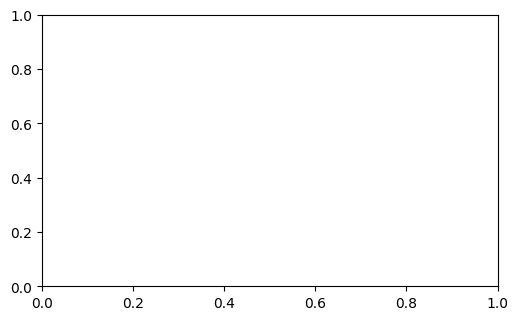

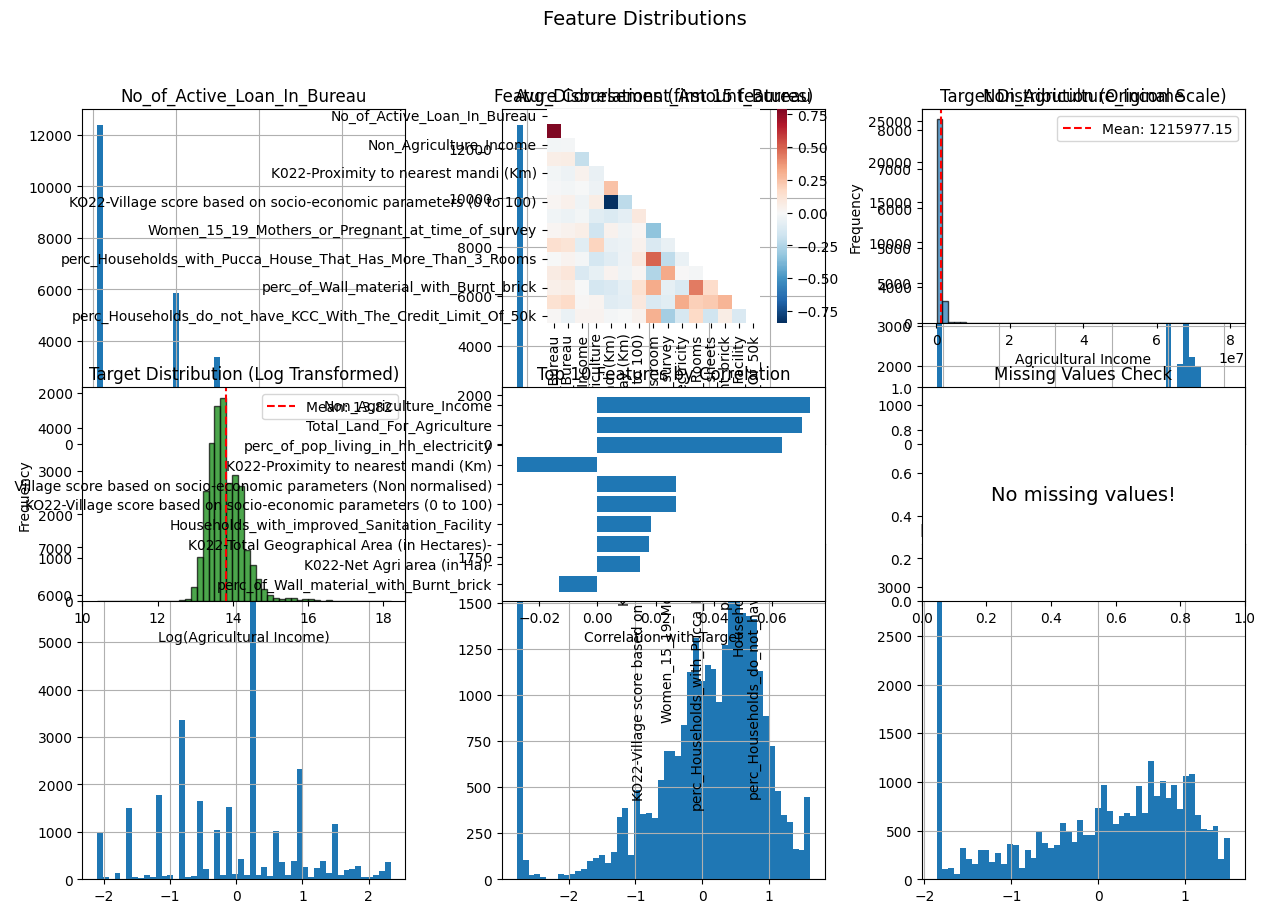

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def final_preprocessing_analysis(X_train, X_val, X_test, 
                                 y_train=None, y_val=None, y_test=None,
                                 y_train_log=None, y_val_log=None, y_test_log=None,
                                 non_agri_dict=None):
    """
    Comprehensive analysis of fully preprocessed data.
    Run this AFTER all preprocessing steps.
    """
    
    print("\n" + "="*80)
    print("FINAL PREPROCESSED DATA ANALYSIS")
    print("="*80)
    
    # ============================================
    # 1. BASIC INFORMATION
    # ============================================
    print("\n📋 BASIC INFORMATION")
    print("-"*60)
    
    print(f"\nFeature sets:")
    print(f"  X_train: {X_train.shape} - {X_train.shape[0]} samples, {X_train.shape[1]} features")
    print(f"  X_val:   {X_val.shape} - {X_val.shape[0]} samples, {X_val.shape[1]} features")
    print(f"  X_test:  {X_test.shape} - {X_test.shape[0]} samples, {X_test.shape[1]} features")
    
    total_samples = X_train.shape[0] + X_val.shape[0] + X_test.shape[0]
    print(f"\nSplit ratios:")
    print(f"  Train: {X_train.shape[0]/total_samples*100:.1f}%")
    print(f"  Val:   {X_val.shape[0]/total_samples*100:.1f}%")
    print(f"  Test:  {X_test.shape[0]/total_samples*100:.1f}%")
    
    if y_train is not None:
        print(f"\nTarget variables:")
        print(f"  y_train: {len(y_train)} samples")
        print(f"  y_val:   {len(y_val)} samples")
        print(f"  y_test:  {len(y_test)} samples")
    
    # ============================================
    # 2. DATA TYPES CHECK
    # ============================================
    print("\n📊 DATA TYPES IN X_TRAIN")
    print("-"*60)
    
    dtype_counts = X_train.dtypes.value_counts()
    for dtype, count in dtype_counts.items():
        print(f"  {dtype}: {count} columns ({count/len(X_train.columns)*100:.1f}%)")
    
    # ============================================
    # 3. MISSING VALUES CHECK (CRITICAL)
    # ============================================
    print("\n🔍 MISSING VALUES CHECK")
    print("-"*60)
    
    missing_train = X_train.isnull().sum().sum()
    missing_val = X_val.isnull().sum().sum()
    missing_test = X_test.isnull().sum().sum()
    
    print(f"  X_train missing: {missing_train} cells ({missing_train/X_train.size*100:.4f}%)")
    print(f"  X_val missing:   {missing_val} cells ({missing_val/X_val.size*100:.4f}%)")
    print(f"  X_test missing:  {missing_test} cells ({missing_test/X_test.size*100:.4f}%)")
    
    if missing_train + missing_val + missing_test == 0:
        print("  ✅ No missing values in any dataset!")
    else:
        print("  ⚠️  Missing values found!")
        # Show columns with missing values
        for name, df in [('Train', X_train), ('Val', X_val), ('Test', X_test)]:
            missing_cols = df.columns[df.isnull().any()].tolist()
            if missing_cols:
                print(f"     {name}: {missing_cols}")
    
    # ============================================
    # 4. INFINITE VALUES CHECK
    # ============================================
    print("\n⚠️  INFINITE VALUES CHECK")
    print("-"*60)
    
    inf_train = np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum()
    inf_val = np.isinf(X_val.select_dtypes(include=[np.number])).sum().sum()
    inf_test = np.isinf(X_test.select_dtypes(include=[np.number])).sum().sum()
    
    print(f"  X_train infinite: {inf_train}")
    print(f"  X_val infinite:   {inf_val}")
    print(f"  X_test infinite:  {inf_test}")
    
    if inf_train + inf_val + inf_test == 0:
        print("  ✅ No infinite values!")
    
    # ============================================
    # 5. COLUMN CONSISTENCY ACROSS SPLITS
    # ============================================
    print("\n🔄 COLUMN CONSISTENCY")
    print("-"*60)
    
    train_cols = set(X_train.columns)
    val_cols = set(X_val.columns)
    test_cols = set(X_test.columns)
    
    if train_cols == val_cols == test_cols:
        print(f"  ✅ All splits have same {len(train_cols)} columns")
        
        # Check column order (optional)
        if list(X_train.columns) == list(X_val.columns) == list(X_test.columns):
            print("  ✅ Columns in same order across all splits")
        else:
            print("  ⚠️  Column order differs - may affect some models")
    else:
        print("  ❌ Column mismatch detected!")
        if train_cols - val_cols:
            print(f"     In train but not val: {train_cols - val_cols}")
        if val_cols - train_cols:
            print(f"     In val but not train: {val_cols - train_cols}")
        if train_cols - test_cols:
            print(f"     In train but not test: {train_cols - test_cols}")
    
    # ============================================
    # 6. FEATURE STATISTICS
    # ============================================
    print("\n📈 FEATURE STATISTICS (First 10 features)")
    print("-"*60)
    
    # Get first 10 numeric columns
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns[:10]
    
    stats_list = []
    for col in numeric_cols:
        stats_list.append({
            'Feature': col,
            'Mean': X_train[col].mean(),
            'Std': X_train[col].std(),
            'Min': X_train[col].min(),
            'Max': X_train[col].max(),
            'Skew': stats.skew(X_train[col].dropna()) if len(X_train[col].dropna()) > 0 else np.nan
        })
    
    stats_df = pd.DataFrame(stats_list)
    print(stats_df.round(4).to_string(index=False))
    
    # ============================================
    # 7. CORRELATION WITH TARGET (if available)
    # ============================================
    if y_train is not None:
        print("\n🔗 TOP 15 FEATURES CORRELATED WITH TARGET")
        print("-"*60)
        
        y_train_np = y_train.values if hasattr(y_train, 'values') else np.array(y_train)
        
        correlations = []
        for col in X_train.select_dtypes(include=[np.number]).columns:
            # Handle potential NaN or constant columns
            col_data = X_train[col].fillna(X_train[col].mean())
            if col_data.std() > 0:  # Avoid constant columns
                corr = np.corrcoef(col_data, y_train_np)[0, 1]
                correlations.append({'Feature': col, 'Correlation': corr})
        
        corr_df = pd.DataFrame(correlations).sort_values('Correlation', ascending=False)
        
        print("\nTop 10 positive correlations:")
        print(corr_df.head(10).to_string(index=False))
        
        print("\nTop 10 negative correlations:")
        print(corr_df.tail(10).to_string(index=False))
    
    # ============================================
    # 8. FEATURE CATEGORIES
    # ============================================
    print("\n🏷️ FEATURE CATEGORIES")
    print("-"*60)
    
    # Mean features
    mean_features = [col for col in X_train.columns if '_mean' in col]
    print(f"\n  Mean features ({len(mean_features)}): {mean_features[:5]}{'...' if len(mean_features)>5 else ''}")
    
    # Std features
    std_features = [col for col in X_train.columns if '_std' in col]
    print(f"  Std features ({len(std_features)}): {std_features[:5]}{'...' if len(std_features)>5 else ''}")
    
    # PCA features
    pca_features = [col for col in X_train.columns if 'PC' in col or 'pca' in col.lower()]
    print(f"  PCA features ({len(pca_features)}): {pca_features}")
    
    # Encoded features
    encoded_features = [col for col in X_train.columns if '_encoded' in col]
    print(f"  Encoded features ({len(encoded_features)}): {encoded_features}")
    
    # One-hot features
    onehot_features = [col for col in X_train.columns if any(x in col for x in ['REGION_', 'SEX_', 'MARITAL_STATUS_', 'soil_type_', 'agro_zone_', 'State_'])]
    print(f"  One-hot features ({len(onehot_features)}): {onehot_features[:5]}{'...' if len(onehot_features)>5 else ''}")
    
    # Ordinal features
    ordinal_features = [col for col in X_train.columns if '_score' in col]
    print(f"  Ordinal features ({len(ordinal_features)}): {ordinal_features}")
    
    # ============================================
    # 9. TARGET VARIABLE ANALYSIS (if available)
    # ============================================
    if y_train is not None and y_val is not None and y_test is not None:
        print("\n🎯 TARGET VARIABLE ANALYSIS")
        print("-"*60)
        
        y_data = [
            (y_train, 'Train'),
            (y_val, 'Val'),
            (y_test, 'Test')
        ]
        
        if y_train_log is not None:
            y_data_log = [
                (y_train_log, 'Train (log)'),
                (y_val_log, 'Val (log)'),
                (y_test_log, 'Test (log)')
            ]
        
        for y_set, name in y_data:
            y_np = y_set.values if hasattr(y_set, 'values') else np.array(y_set)
            print(f"\n  {name}:")
            print(f"     Mean: {y_np.mean():.4f}")
            print(f"     Std:  {y_np.std():.4f}")
            print(f"     Min:  {y_np.min():.4f}")
            print(f"     Max:  {y_np.max():.4f}")
            print(f"     Skew: {stats.skew(y_np):.4f}")
    
    # ============================================
    # 10. NON-AGRICULTURAL INCOME ANALYSIS
    # ============================================
    if non_agri_dict is not None:
        print("\n💰 NON-AGRICULTURAL INCOME ANALYSIS")
        print("-"*60)
        
        for name, series in non_agri_dict.items():
            if name in ['train', 'val', 'test']:
                values = series.values if hasattr(series, 'values') else np.array(series)
                print(f"\n  {name.capitalize()}:")
                print(f"     Mean: ₹{values.mean():,.2f}")
                print(f"     Std:  ₹{values.std():,.2f}")
                print(f"     Min:  ₹{values.min():,.2f}")
                print(f"     Max:  ₹{values.max():,.2f}")
    
    # ============================================
    # 11. MULTICOLLINEARITY CHECK
    # ============================================
    print("\n📊 MULTICOLLINEARITY CHECK (Top 20 features)")
    print("-"*60)
    
    # Take first 20 numeric columns for correlation matrix
    sample_cols = X_train.select_dtypes(include=[np.number]).columns[:20]
    if len(sample_cols) > 1:
        corr_matrix = X_train[sample_cols].corr().abs()
        
        # Find highly correlated pairs
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        high_corr = []
        
        for i in range(len(upper_tri.columns)):
            for j in range(i+1, len(upper_tri.columns)):
                if upper_tri.iloc[i, j] > 0.8:
                    high_corr.append((upper_tri.columns[i], upper_tri.columns[j], upper_tri.iloc[i, j]))
        
        if high_corr:
            print(f"  Found {len(high_corr)} highly correlated pairs (>0.8):")
            for f1, f2, val in high_corr[:10]:  # Show first 10
                print(f"     {f1} ↔ {f2}: {val:.3f}")
            if len(high_corr) > 10:
                print(f"     ... and {len(high_corr)-10} more")
        else:
            print("  ✅ No highly correlated pairs found")
    
    # ============================================
    # 12. SUMMARY STATISTICS
    # ============================================
    print("\n" + "="*80)
    print("SUMMARY STATISTICS")
    print("="*80)
    
    summary = {
        'Total Features': X_train.shape[1],
        'Training Samples': X_train.shape[0],
        'Validation Samples': X_val.shape[0],
        'Test Samples': X_test.shape[0],
        'Missing Values': missing_train + missing_val + missing_test,
        'Numeric Features': len(X_train.select_dtypes(include=[np.number]).columns),
        'Mean Features': len(mean_features),
        'Std Features': len(std_features),
        'PCA Features': len(pca_features),
        'Encoded Features': len(encoded_features),
        'One-hot Features': len(onehot_features),
        'Ordinal Features': len(ordinal_features)
    }
    
    if y_train is not None:
        summary['Target Mean (Train)'] = f"{y_train.mean():.4f}"
        summary['Target Std (Train)'] = f"{y_train.std():.4f}"
    
    for key, value in summary.items():
        print(f"  {key}: {value}")
    
    return summary


# ============================================
# VISUALIZATION FUNCTION
# ============================================

def plot_final_analysis(X_train, y_train=None, y_train_log=None, top_n=10):
    """
    Create visualizations of the final preprocessed data.
    """
    
    fig = plt.figure(figsize=(20, 12))
    
    # 1. Feature distributions (first 6 numeric features)
    plt.subplot(3, 3, 1)
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns[:6]
    X_train[numeric_cols].hist(bins=50, figsize=(15, 10), layout=(2, 3))
    plt.suptitle('Feature Distributions', fontsize=14)
    
    # 2. Correlation heatmap (first 15 features)
    plt.subplot(3, 3, 2)
    sample_cols = X_train.select_dtypes(include=[np.number]).columns[:15]
    if len(sample_cols) > 1:
        corr = X_train[sample_cols].corr()
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, 
                    square=True, annot=False, fmt='.2f')
        plt.title('Feature Correlations (first 15 features)')
    
    # 3. Target distribution (if available)
    if y_train is not None:
        plt.subplot(3, 3, 3)
        y_np = y_train.values if hasattr(y_train, 'values') else np.array(y_train)
        plt.hist(y_np, bins=50, edgecolor='black', alpha=0.7)
        plt.axvline(y_np.mean(), color='red', linestyle='--', label=f'Mean: {y_np.mean():.2f}')
        plt.xlabel('Agricultural Income')
        plt.ylabel('Frequency')
        plt.title('Target Distribution (Original Scale)')
        plt.legend()
    
    # 4. Log target distribution (if available)
    if y_train_log is not None:
        plt.subplot(3, 3, 4)
        y_log_np = y_train_log.values if hasattr(y_train_log, 'values') else np.array(y_train_log)
        plt.hist(y_log_np, bins=50, edgecolor='black', alpha=0.7, color='green')
        plt.axvline(y_log_np.mean(), color='red', linestyle='--', label=f'Mean: {y_log_np.mean():.2f}')
        plt.xlabel('Log(Agricultural Income)')
        plt.ylabel('Frequency')
        plt.title('Target Distribution (Log Transformed)')
        plt.legend()
    
    # 5. Feature importance proxy (correlation with target)
    if y_train is not None:
        plt.subplot(3, 3, 5)
        y_np = y_train.values if hasattr(y_train, 'values') else np.array(y_train)
        correlations = []
        features = []
        for col in X_train.select_dtypes(include=[np.number]).columns[:20]:
            col_data = X_train[col].fillna(X_train[col].mean())
            if col_data.std() > 0:
                corr = np.corrcoef(col_data, y_np)[0, 1]
                correlations.append(corr)
                features.append(col)
        
        if correlations:
            idx = np.argsort(np.abs(correlations))[-top_n:]
            plt.barh(range(len(idx)), np.array(correlations)[idx])
            plt.yticks(range(len(idx)), np.array(features)[idx])
            plt.xlabel('Correlation with Target')
            plt.title(f'Top {top_n} Features by Correlation')
    
    # 6. Missing values heatmap
    plt.subplot(3, 3, 6)
    missing = X_train.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing) > 0:
        plt.bar(range(len(missing)), missing.values)
        plt.xticks(range(len(missing)), missing.index, rotation=45, ha='right')
        plt.ylabel('Missing Values')
        plt.title('Missing Values by Feature')
    else:
        plt.text(0.5, 0.5, 'No missing values!', ha='center', va='center', fontsize=14)
        plt.title('Missing Values Check')
    
    plt.tight_layout()
    plt.show()


# ============================================
# USAGE
# ============================================

# Run after your preprocessing pipeline
summary = final_preprocessing_analysis(
    X_train=X_train_pp,
    X_val=X_val_pp,
    X_test=X_test_pp,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
    y_train_log=y_train_log,
    y_val_log=y_val_log,
    y_test_log=y_test_log,
    non_agri_dict=non_agri_dict  # if you have it
)

# Create visualizations
plot_final_analysis(
    X_train=X_train_pp,
    y_train=y_train,
    y_train_log=y_train_log,
    top_n=10
)

In [18]:
summ(X_train_pp)

,dtype,missing,missing_%,unique_values
No_of_Active_Loan_In_Bureau,float64,0,0.0,14
Avg_Disbursement_Amount_Bureau,float64,0,0.0,9307
Non_Agriculture_Income,float64,0,0.0,1876
Total_Land_For_Agriculture,float64,0,0.0,258
K022-Proximity to nearest mandi (Km),float64,0,0.0,327
...,...,...,...,...
State_PUNJAB,float64,0,0.0,2
State_RAJASTHAN,float64,0,0.0,2
State_TELANGANA,float64,0,0.0,2
State_UTTAR PRADESH,float64,0,0.0,2


## Export Preprocessed Files

In [19]:
os.makedirs("preprocessed_data", exist_ok=True)

X_train_pp.to_csv("preprocessed_data/X_train_pp.csv", index=False)
X_val_pp.to_csv("preprocessed_data/X_val_pp.csv", index=False)
X_test_pp.to_csv("preprocessed_data/X_test_pp.csv", index=False)

# Export LOG-TRANSFORMED targets — use these for training
y_train_log.to_csv("preprocessed_data/y_train_log.csv", index=False)
y_val_log.to_csv("preprocessed_data/y_val_log.csv", index=False)
y_test_log.to_csv("preprocessed_data/y_test_log.csv", index=False)

pd.Series(y_train, name='agri_income').to_csv("preprocessed_data/y_train_raw.csv", index=False)
pd.Series(y_val,   name='agri_income').to_csv("preprocessed_data/y_val_raw.csv",   index=False)
pd.Series(y_test,  name='agri_income').to_csv("preprocessed_data/y_test_raw.csv",  index=False)

non_agri_train.to_csv("preprocessed_data/non_agri_train.csv", index=False)
non_agri_val.to_csv("preprocessed_data/non_agri_val.csv", index=False)
non_agri_test.to_csv("preprocessed_data/non_agri_test.csv", index=False)

In [20]:
os.makedirs("final_data", exist_ok=True)
X_final_pp.to_csv("final_data/X_final_pp.csv", index=False)
pd.Series(farmer_id_final,  name='farmer_id').to_csv("final_data/farmer_id_final.csv",  index=False)